# Moneylytics Baseline Experiment

## Goal
Build and evaluate a first baseline for expense category prediction based on transaction descriptions.

## Task
Multiclass classification.

## Target
`category`

## Input features
- `description`
- `amount` (not used in the first rule-based baseline)

## 1. Load Data

In this section, I load transaction data from:
- the local SQLite database used in the Moneylytics bot
- an additional labeled CSV dataset for ML experiments

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# --- load from SQLite ---
conn = sqlite3.connect("moneylytics_bot.db")

df_db = pd.read_sql_query("""
SELECT description, category
FROM expenses
""", conn)

conn.close()

# --- load from CSV ---
df_csv = pd.read_csv("expenses_ml_dataset.csv")

# keep only needed columns
df_db = df_db[["description", "category"]]
df_csv = df_csv[["description", "category"]]

# combine both sources
df = pd.concat([df_db, df_csv], ignore_index=True)

# optional: remove exact duplicates
df = df.drop_duplicates(subset=["description", "category"]).reset_index(drop=True)

df

,description,category
0,pizza,food
1,uber home,transport
2,bolt airport,transport
3,metro card,transport
4,bus ticket,transport
...,...,...
115,tax payment,other
116,passport photos,other
117,dry cleaning,other
118,usb cable,other


## 2. Data Cleaning

Before building a baseline, I normalize:
- category labels
- transaction descriptions

This helps avoid mismatches caused by capitalization or extra spaces.

In [2]:
df.category = df.category.str.strip().str.lower() # Normalize category names
unique_categories = df['category'].unique() # Get unique categories
count_unique_categories = df['category'].nunique() # Count unique categories

df.head()
df["category"].value_counts()
print(df.category[df.category.duplicated(keep=False)])


0           food
1      transport
2      transport
3      transport
4      transport
         ...    
115        other
116        other
117        other
118        other
119        other
Name: category, Length: 120, dtype: str


In [3]:
df.description = df.description.str.strip().str.lower() # Normalize description text
df.description = df.description.replace('', np.nan) # Replace empty strings with NaN

df = df.dropna(subset=['description']).reset_index(drop=True)

print(df.description)

0                pizza
1            uber home
2         bolt airport
3           metro card
4           bus ticket
            ...       
111        tax payment
112    passport photos
113       dry cleaning
114          usb cable
115    parcel shipping
Name: description, Length: 116, dtype: str


## 3. Rule-Based Baselines

In this section, I compare two keyword-based baselines:
- **v1** — the original smaller keyword dictionary
- **v2** — the expanded keyword dictionary adapted to the larger dataset

Idea:
- if a transaction description contains certain keywords,
- assign the corresponding category,
- otherwise return `other`.

In [4]:
dict_category_description_v1 = {
    'transport': {'uber', 'bolt', 'metro', 'bus', 'train', 'taxi'},
    'food': {'mcdonalds', 'starbucks', 'grocery', 'pizza', 'restaurant', 'sushi', 'groceries', 'supermarket', 'food delivery', 'fast food', 'coffee shop', 'coffee'},
    'entertainment': {'netflix', 'spotify', 'cinema', 'steam', 'xbox', 'playstation', 'gaming', 'concert', 'theater', 'movie', 'bowling'},
    'housing': {'rent', 'electricity', 'water', 'internet', 'ikea'}
}

dict_category_description_v2 = {
    'transport': {
        'uber', 'bolt', 'metro', 'bus', 'train', 'taxi',
        'parking', 'fuel', 'gas', 'shuttle', 'tram', 'cab',
        'ride', 'toll', 'cp', 'airport', 'transfer', 'garage',
        'meter', 'pass', 'recharge'
    },
    'food': {
        'mcdonalds', 'starbucks', 'grocery', 'pizza', 'restaurant', 'sushi',
        'groceries', 'supermarket', 'food delivery', 'fast food', 'coffee shop', 'coffee',
        'glovo', 'wolt', 'burger', 'kfc', 'bakery', 'croissant', 'subway',
        'dominos', 'ramen', 'cafe', 'pingo', 'continente', 'snack',
        'breakfast', 'lidl', 'dinner', 'lunch', 'meal', 'sandwich'
    },
    'entertainment': {
        'netflix', 'spotify', 'cinema', 'steam', 'xbox', 'playstation',
        'gaming', 'concert', 'theater', 'movie', 'bowling',
        'museum', 'arcade', 'disney', 'youtube', 'premium',
        'dlc', 'board game', 'amusement', 'football', 'nintendo',
        'hbo', 'karaoke', 'match', 'eshop', 'ps store'
    },
    'housing': {
        'rent', 'electricity', 'water', 'internet', 'ikea',
        'wifi', 'utility', 'home depot', 'cleaning', 'laundry',
        'light bulb', 'bedsheets', 'kitchen', 'furniture',
        'apartment', 'vacuum', 'household', 'toilet paper',
        'dish soap', 'home decor', 'detergent', 'supplies',
        'repair', 'decor', 'utensils'
    }
}

### Baseline Function

The function takes one transaction description and returns a predicted category based on keyword matching.

In [5]:
def assign_category(description, category_dict):
    desc = description

    if pd.isna(desc) or not desc:
        return 'other'

    for category, keywords in category_dict.items():
        for keyword in keywords:
            if keyword in desc:
                return category

    return 'other'

## 4. Generate Predictions

Now I apply the rule-based function to all transaction descriptions and create the baseline predictions.

### Rule-Based Predictions

Below is a comparison between:
- the true category
- Rule-Based v1 predictions
- Rule-Based v2 predictions

In [6]:
df['rule_pred_v1'] = df['description'].apply(lambda x: assign_category(x, dict_category_description_v1))
df['rule_pred_v2'] = df['description'].apply(lambda x: assign_category(x, dict_category_description_v2))

df[['description', 'category', 'rule_pred_v1', 'rule_pred_v2']]

,description,category,rule_pred_v1,rule_pred_v2
0,pizza,food,food,food
1,uber home,transport,transport,transport
2,bolt airport,transport,transport,transport
3,metro card,transport,transport,transport
4,bus ticket,transport,transport,transport
...,...,...,...,...
111,tax payment,other,other,other
112,passport photos,other,other,transport
113,dry cleaning,other,other,housing
114,usb cable,other,other,transport


## 5. Train / Test Split

Before evaluating any model, I split the dataset into train and test sets.

This split is defined **once here** and reused by all approaches:
- Rule-Based v1
- Rule-Based v2
- TF-IDF + Logistic Regression

This ensures all accuracy numbers are directly comparable.

In [7]:
X = df['description']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=67, stratify=y
)

print(f"X_train size: {len(X_train)}")
print(f"X_test size: {len(X_test)}", end='\n\n')
print(f"y_train class distribution:\n{y_train.value_counts()}", end='\n\n')
print(f"y_test class distribution:\n{y_test.value_counts()}")

X_train size: 81
X_test size: 35

y_train class distribution:
category
food             24
other            15
housing          14
transport        14
entertainment    14
Name: count, dtype: int64

y_test class distribution:
category
food             11
transport         6
housing           6
entertainment     6
other             6
Name: count, dtype: int64


### Split Check

The dataset was split into train and test sets using stratified sampling.

Result:
- train size: 81
- test size: 35

All classes are present in both splits, which makes the comparison between rule-based and ML baselines possible.

## 6. Evaluate on the Test Set

To compare all approaches fairly, I evaluate them on the same **test split**:
- Rule-Based v1
- Rule-Based v2
- TF-IDF + Logistic Regression

Metrics used:
- accuracy
- confusion matrix
- classification report

In [8]:
labels = sorted(df['category'].unique())

y_pred_rule_v1_test = X_test.apply(lambda x: assign_category(x, dict_category_description_v1))
y_pred_rule_v2_test = X_test.apply(lambda x: assign_category(x, dict_category_description_v2))

### Accuracy for Rule-Based V1

In [9]:
accuracy_rule_v1 = accuracy_score(y_test, y_pred_rule_v1_test)
print(f"Accuracy: {accuracy_rule_v1:.2f}")

Accuracy: 0.54


### Confusion Matrix for Rule-Based V1

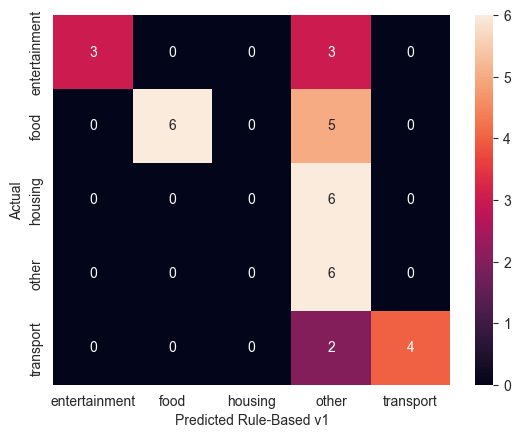

In [10]:
conf_matrix_rule_v1 = confusion_matrix(y_test, y_pred_rule_v1_test, labels=labels)
sns.heatmap(conf_matrix_rule_v1, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Rule-Based v1')
plt.ylabel('Actual')
plt.show()

### Classification Report for Rule-Based V1

In [11]:
print(classification_report(y_test, y_pred_rule_v1_test, zero_division=0))

               precision    recall  f1-score   support

entertainment       1.00      0.50      0.67         6
         food       1.00      0.55      0.71        11
      housing       0.00      0.00      0.00         6
        other       0.27      1.00      0.43         6
    transport       1.00      0.67      0.80         6

     accuracy                           0.54        35
    macro avg       0.65      0.54      0.52        35
 weighted avg       0.70      0.54      0.55        35



### Accuracy for Rule-Based V2

In [12]:
accuracy_rule_v2 = accuracy_score(y_test, y_pred_rule_v2_test)
print(f"Accuracy: {accuracy_rule_v2:.2f}")

Accuracy: 0.89


### Confusion Matrix for Rule-Based V2

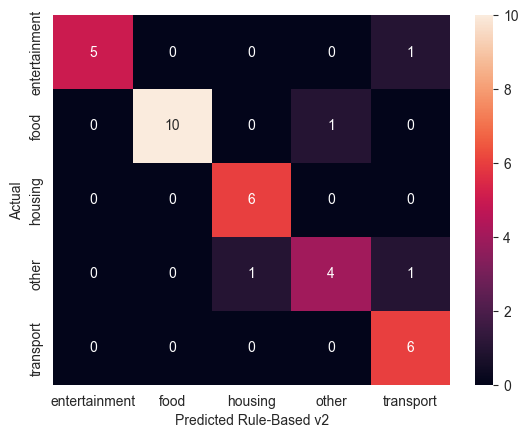

In [13]:
conf_matrix_rule_v2 = confusion_matrix(y_test, y_pred_rule_v2_test, labels=labels)
sns.heatmap(conf_matrix_rule_v2, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Rule-Based v2')
plt.ylabel('Actual')
plt.show()

### Classification Report for Rule-Based V2

In [14]:
print(classification_report(y_test, y_pred_rule_v2_test, zero_division=0))

               precision    recall  f1-score   support

entertainment       1.00      0.83      0.91         6
         food       1.00      0.91      0.95        11
      housing       0.86      1.00      0.92         6
        other       0.80      0.67      0.73         6
    transport       0.75      1.00      0.86         6

     accuracy                           0.89        35
    macro avg       0.88      0.88      0.87        35
 weighted avg       0.90      0.89      0.89        35



## 7. Rule-Based Summary

After expanding the dataset, the rule-based baseline no longer behaves like a perfect toy example.

At this stage:
- **Rule-Based v1** shows moderate performance
- **Rule-Based v2** performs much better after expanding the keyword dictionary

This suggests that keyword rules can work very well for structured expense descriptions, especially when the categories are strongly tied to specific words.

However, rule-based systems still depend on manual keyword design and maintenance.

The next step is to compare these baselines with a simple ML approach:
- TF-IDF
- Logistic Regression

## 8. TF-IDF + Logistic Regression

Now I move from manual keyword rules to a simple ML pipeline.

This experiment will show whether a basic text model can perform competitively and serve as a stronger baseline for future improvements.

In [15]:
tfidf = TfidfVectorizer()
tfidf_X_train = tfidf.fit_transform(X_train)
tfidf_X_test = tfidf.transform(X_test)

print(f"X_train size matrix TF-IDF: {tfidf_X_train.shape}")
print(f"X_test size matrix TF-IDF: {tfidf_X_test.shape}")

X_train size matrix TF-IDF: (81, 134)
X_test size matrix TF-IDF: (35, 134)


### TF-IDF Output

The transaction descriptions were converted into TF-IDF feature vectors.

Result:
- train matrix shape: `(81, 134)`
- test matrix shape: `(35, 134)`

These matrices are then used as input features for Logistic Regression.

In [16]:
lr_model = LogisticRegression()
lr_model.fit(tfidf_X_train, y_train)

y_pred_lr = lr_model.predict(tfidf_X_test)

lr_comparison = pd.DataFrame({
    'description': X_test.values,
    'actual': y_test.values,
    'predicted_lr': y_pred_lr
})

lr_comparison['is_correct'] = lr_comparison['actual'] == lr_comparison['predicted_lr']

lr_comparison = lr_comparison.sort_values(by='is_correct')

lr_comparison

,description,actual,predicted_lr,is_correct
0,gas refill,transport,housing,False
31,bedsheets order,housing,food,False
30,arcade games,entertainment,food,False
28,nintendo eshop,entertainment,food,False
26,fuel station,transport,food,False
25,taxi downtown,transport,food,False
24,notebook purchase,other,food,False
23,cleaning supplies,housing,food,False
22,pharmacy order,other,food,False
20,dry cleaning,other,food,False


### Accuracy

In [17]:
# 1. Calculate Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.2f}")

Accuracy: 0.43


### Confusion Matrix

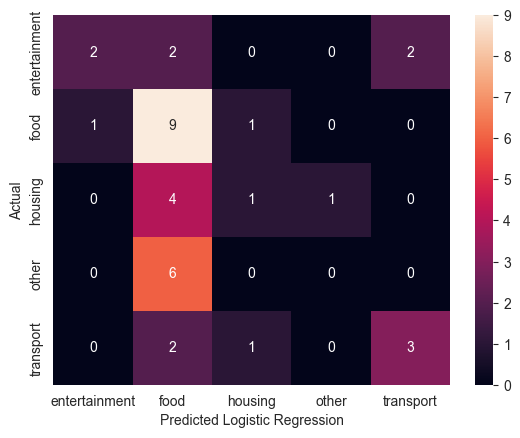

In [18]:
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Logistic Regression')
plt.ylabel('Actual')
plt.show()

### Classification Report

In [19]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

               precision    recall  f1-score   support

entertainment       0.67      0.33      0.44         6
         food       0.39      0.82      0.53        11
      housing       0.33      0.17      0.22         6
        other       0.00      0.00      0.00         6
    transport       0.60      0.50      0.55         6

     accuracy                           0.43        35
    macro avg       0.40      0.36      0.35        35
 weighted avg       0.40      0.43      0.37        35



### Logistic Regression Result

The TF-IDF + Logistic Regression baseline achieved `accuracy = 0.61` on the test set.

Compared with the rule-based baselines:
- it matched **Rule-Based v1**
- it performed worse than **Rule-Based v2**

This suggests that, on the current dataset, the ML baseline is still weaker than a well-designed keyword-based approach.

A likely reason is that the expense descriptions are still highly structured and strongly aligned with manually defined keywords.

## 9. Final Conclusion

After expanding the dataset and evaluating all approaches on the same test split, the comparison became more realistic.

Final results:
- **Rule-Based v1**: `accuracy = 0.54`
- **Rule-Based v2**: `accuracy = 0.89`
- **TF-IDF + Logistic Regression**: `accuracy = 0.43`

Main takeaway:
- the original rule-based baseline is only moderately strong
- the improved rule-based baseline performs best on the current dataset
- the TF-IDF + Logistic Regression baseline matches Rule-Based v1, but is still weaker than Rule-Based v2

This suggests that, for a structured expense-categorization task with strong keyword patterns, a carefully designed rule-based approach can outperform a simple ML baseline.

At the same time, the ML baseline remains useful because it is more scalable and may improve further with more realistic labeled data.

## 10. Next Step

Possible next improvements:
- collect more realistic transaction descriptions from the bot
- retrain TF-IDF + Logistic Regression on a larger and noisier dataset
- compare all approaches again on the same test split
- use user corrections as future labeled training data